In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
import numpy as np
import cv2 #OpenCV

In [2]:
# load MNIST data

In [3]:
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
train_images[1]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,  51, 159, 253, 159,  50,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  48, 238, 252, 252, 252, 237,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         54, 227, 253, 252, 239, 233, 252,  57,   6,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  10,  60,
        224, 252, 253, 252, 202,  84, 252, 253, 122,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 163, 252,
        252, 252, 253, 252, 252,  96, 189, 253, 167,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  51, 238, 253,
        253, 190, 114, 253, 228,  47,  79, 255, 168,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  48, 238, 252, 252,
        179,  12,  75, 121,  21,   0,   0, 253, 243,  50,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  38, 165, 253, 233, 208,
         84,   0,   0,   0,   0,   0,   0, 253, 252, 165,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   7, 178, 252, 240,  71,  19,
         28,   0,   0,   0,   0,   0,   0, 253, 252, 195,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  57, 252, 252,  63,   0,   0,
          0,   0,   0,   0,   0,   0,   0, 253, 252, 195,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0, 198, 253, 190,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0, 255, 253, 196,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  76, 246, 252, 112,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0, 253, 252, 148,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  85, 252, 230,  25,   0,   0,   0,
          0,   0,   0,   0,   0,   7, 135, 253, 186,  12,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  85, 252, 223,   0,   0,   0,   0,
          0,   0,   0,   0,   7, 131, 252, 225,  71,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  85, 252, 145,   0,   0,   0,   0,
          0,   0,   0,  48, 165, 252, 173,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  86, 253, 225,   0,   0,   0,   0,
          0,   0, 114, 238, 253, 162,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  85, 252, 249, 146,  48,  29,  85,
        178, 225, 253, 223, 167,  56,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  85, 252, 252, 252, 229, 215, 252,
        252, 252, 196, 130,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  28, 199, 252, 252, 253, 252, 252,
        233, 145,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  25, 128, 252, 253, 252, 141,
         37,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   

In [5]:
train_labels[1]

np.uint8(0)

In [6]:
train_images[20]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,  38, 190,  25,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,  13,  25,  10,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0, 112, 252, 125,   4,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0, 132, 252, 113,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,  61, 252, 252,  36,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0, 132, 252, 240,  79,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,  84, 252, 252,  36,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0, 132, 252, 252, 238,  52,   0,   0,   0,   0,   0,
          0,   0,   0,  12, 198, 252, 252, 122,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,  99, 252, 252, 252, 181,  17,   0,   0,   0,   0,
          0,   0,   0,  49, 252, 252, 252, 122,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   3, 125, 252, 252, 252, 100,   0,   0,   0,   0,
          0,   0,   0,  26, 218, 252, 252,  36,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,  15, 216, 252, 252, 207,  19,   0,   0,   0,
          0,   0,   0,  49, 252, 252, 252,  36,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0, 157, 252, 252, 252,  48,   0,   0,   0,
          6, 109, 109, 194, 252, 252, 252,  36,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0, 100, 252, 252, 252, 105,   0,  58, 116,
        128, 252, 252, 252, 252, 252, 212,  19,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0, 164, 253, 253, 253, 253, 253, 253,
        255, 253, 253, 253, 253, 253, 253,  99,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  49, 252, 252, 252, 252, 252, 252,
        253, 252, 252, 252, 252, 252, 252, 155,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  49, 252, 252, 252, 252, 252, 252,
        217, 216, 141, 126, 252, 252, 252, 155,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  49, 252, 252, 252, 234, 204,  89,
          0,   0,   0,  49, 252, 252, 252, 155,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  14, 158, 192, 151,  45,   0,   0,
          0,   0,   0,  49, 252, 252, 252, 225,  17,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,  49, 252, 252, 252, 252,  23,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,  33, 228, 252, 252, 252, 157,   4,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,  55, 229, 252, 252, 252,  11,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,  53, 232, 252, 252,  63,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,  90, 206, 131,  11,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   

In [7]:
train_labels[20]

np.uint8(4)

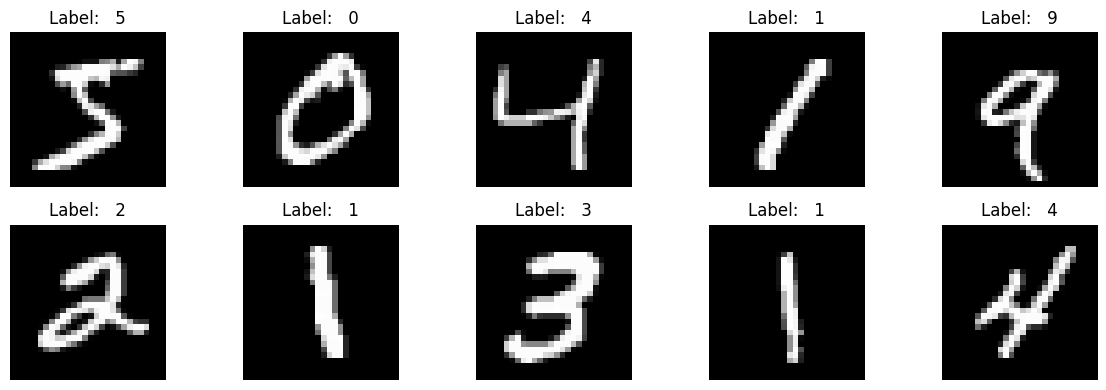

In [8]:
plt.figure(figsize = (12, 4))
for i in range(10):
  plt.subplot(2, 5, i+1)
  img = train_images[i].reshape(28, 28)
  plt.imshow(img, cmap = 'gray')
  plt.title(f"Label:   {train_labels[i]}")
  plt.axis('off')

plt.tight_layout()

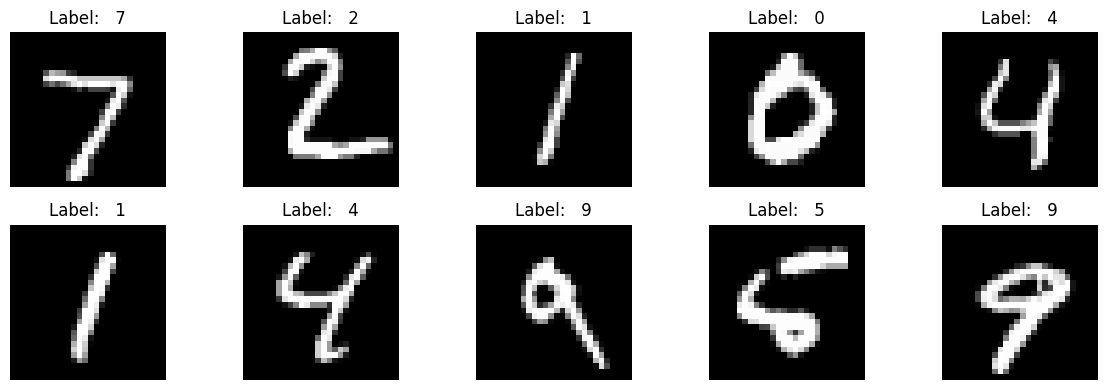

In [9]:
plt.figure(figsize = (12, 4))
for i in range(10):
  plt.subplot(2, 5, i+1)
  img = test_images[i].reshape(28, 28)
  plt.imshow(img, cmap = 'gray')
  plt.title(f"Label:   {test_labels[i]}")
  plt.axis('off')

plt.tight_layout()

In [10]:
# normalisation of images manually and reshape

In [11]:
train_images = train_images.astype('float32')/255
test_images = test_images.astype('float32')/255

In [12]:
train_images = train_images.reshape((-1, 28, 28, 1))
test_images = test_images.reshape((-1, 28, 28, 1))

In [13]:
# one hot encoding

In [14]:
train_labels = tf.keras.utils.to_categorical(train_labels)
test_labels = tf.keras.utils.to_categorical(test_labels)

In [15]:
train_labels[1]

array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [16]:
# defining CNN
# Model Arcgitecture

In [17]:
def create_model():
  return models.Sequential([
      layers.Input(shape=(28, 28, 1)),
      # layer1
      layers.RandomTranslation(0.1, 0.1),
      layers.RandomRotation(0.05),
      # layer2
      layers.Conv2D(32, (3,3), activation = 'relu'),
      layers.BatchNormalization(),
      layers.MaxPooling2D((2,2)),
      # layer3
      layers.Conv2D(64, (3,3), activation = 'relu'),
      layers.BatchNormalization(),
      layers.MaxPooling2D((2,2)),
      layers.Flatten(),

      # ANN
      layers.Dense(128, activation = 'relu'),
      layers.Dropout(0.3),
      layers.Dense(10, activation = 'softmax')
  ])

In [18]:
model = create_model()
model.compile(optimizer = 'adam',
              loss = 'categorical_crossentropy',
              metrics = ['accuracy']
              )

In [19]:
callbacks_list = [
    callbacks.EarlyStopping(patience = 5, restore_best_weights =  True),
    callbacks.ReduceLROnPlateau(factor = 0.2, patience = 3)
]

In [20]:
history = model.fit(train_images, train_labels, epochs = 30, validation_split = 0.1, callbacks = callbacks_list)

Epoch 1/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.8228 - loss: 0.5681 - val_accuracy: 0.9752 - val_loss: 0.0889 - learning_rate: 0.0010
Epoch 2/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9551 - loss: 0.1506 - val_accuracy: 0.9823 - val_loss: 0.0625 - learning_rate: 0.0010
Epoch 3/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9657 - loss: 0.1168 - val_accuracy: 0.9852 - val_loss: 0.0514 - learning_rate: 0.0010
Epoch 4/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9693 - loss: 0.1057 - val_accuracy: 0.9888 - val_loss: 0.0418 - learning_rate: 0.0010
Epoch 5/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9733 - loss: 0.0913 - val_accuracy: 0.9873 - val_loss: 0.0511 - learning_rate: 0.0010
Epoch 6/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9757 - loss: 0.0842 - val_accuracy: 0.9897 - val_loss: 0.0444 - learning_rate: 0.0010
Epoch 7/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9

In [21]:
# opencv prediction pipeline

In [22]:
def predict_with_opencv(image_path, model):
  # load as grayscale
  img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
  # gaussian blur to reduce noise
  img = cv2.GaussianBlur(img, (5, 5), 0)
  # thresholding: turning gray or shadowy to black n white
  _, img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
  # resize
  img = cv2.resize(img, (28, 28), interpolation = cv2.INTER_AREA)
  # final prep
  img_array = img.astype('float32') / 255
  img_array = img_array.reshape(1, 28, 28, 1)

  prediction = model.predict(img_array)
  return np.argmax(prediction[0]), np.max(prediction[0])

In [23]:
model.save('mnist_opencv_model.keras')

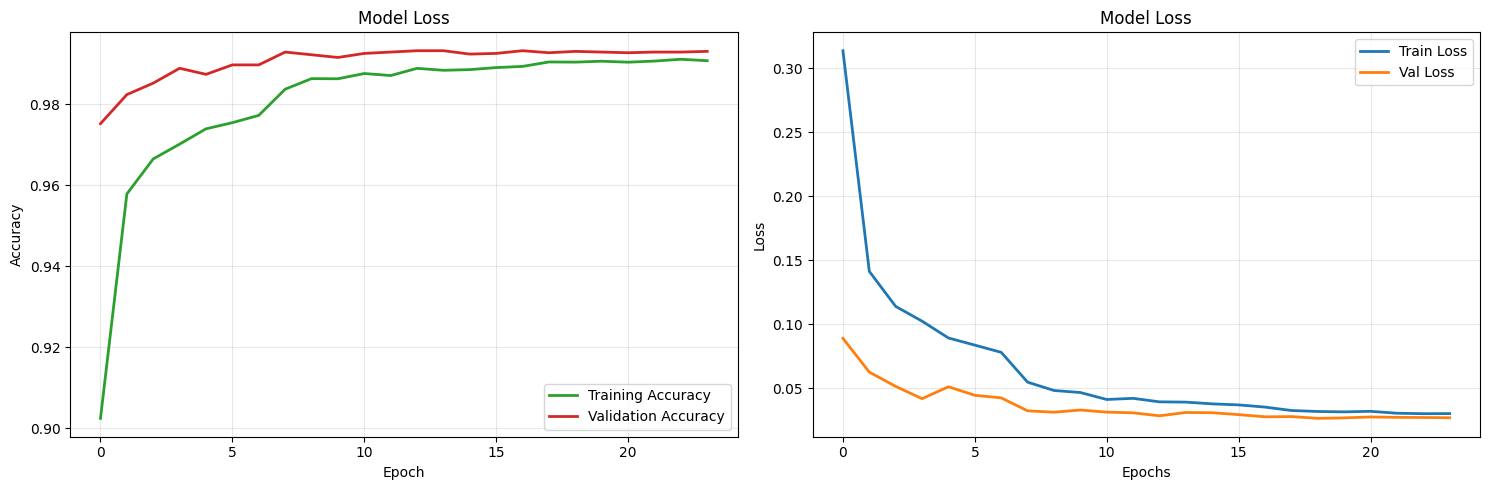

In [24]:
plt.figure(figsize = (15, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label = 'Training Accuracy', color='#2ca02c', lw=2)
plt.plot(history.history['val_accuracy'], label = 'Validation Accuracy', color='#d62728', lw=2)
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='#1f77b4', lw=2)
plt.plot(history.history['val_loss'], label='Val Loss', color='#ff7f0e', lw=2)
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [46]:
def predict_digit(image_path):
    # 1. Load Original
    raw_img = cv2.imread(image_path)
    raw_img_rgb = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB) # For correct colors in plot

    # 2. Process (The 'MNIST-ifier')
    gray = cv2.cvtColor(raw_img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    _, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    # 1. Find the exact box where the digit is (Auto-Crop)
    # This ignores the large shadows on the rest of the paper
    coords = cv2.findNonZero(thresh)
    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)
        thresh = thresh[y:y+h, x:x+w]

        # Add a small black border so the digit isn't touching the edge
        thresh = cv2.copyMakeBorder(thresh, 4, 4, 4, 4, cv2.BORDER_CONSTANT, value=0)

    # 2. Thicken the lines (Dilation)
    # This ensures the thin pen stroke doesn't disappear when shrinking to 28x28
    kernel = np.ones((2,2), np.uint8)
    thresh = cv2.dilate(thresh, kernel, iterations=1)

    final_img = cv2.resize(thresh, (28, 28), interpolation=cv2.INTER_AREA)

    # 3. Predict
    img_array = final_img.astype('float32') / 255.0
    prediction = model.predict(img_array.reshape(1, 28, 28, 1), verbose=0)
    digit, conf = np.argmax(prediction[0]), np.max(prediction[0])

    # 4. Show image
    plt.figure(figsize=(10, 4))
    plt.imshow(raw_img_rgb); plt.title("Original Image"); plt.axis('off')
    plt.show()

    print(f"Prediction: {digit} ({conf*100:.1f}% confidence)")
    return digit, conf

In [47]:
# def predict_digit(image_path):
#     # 1. Load and Grayscale
#     raw_img = cv2.imread(image_path)
#     gray = cv2.cvtColor(raw_img, cv2.COLOR_BGR2GRAY)

#     # 2. Use Adaptive Thresholding (Better for shadows than Otsu)
#     # This looks at small neighborhoods of pixels rather than the whole image
#     thresh = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
#                                    cv2.THRESH_BINARY_INV, 11, 2)

#     # 3. Clean up small dots (noise)
#     kernel = np.ones((3,3), np.uint8)
#     thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

#     # 4. AUTO-CROP to the digit
#     coords = cv2.findNonZero(thresh)
#     if coords is not None:
#         x, y, w, h = cv2.boundingRect(coords)
#         thresh = thresh[y:y+h, x:x+w]
#         # Add a 10% black border to help the CNN see the edges
#         pad = int(max(w, h) * 0.1)
#         thresh = cv2.copyMakeBorder(thresh, pad, pad, pad, pad, cv2.BORDER_CONSTANT, value=0)

#     # 5. Resize and Predict
#     final_img = cv2.resize(thresh, (28, 28), interpolation=cv2.INTER_AREA)
#     img_array = final_img.astype('float32') / 255.0
#     prediction = model.predict(img_array.reshape(1, 28, 28, 1), verbose=0)

#     digit, conf = np.argmax(prediction[0]), np.max(prediction[0])

#     # Show the results
#     plt.subplot(1, 2, 1); plt.imshow(cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)); plt.title("Original")
#     plt.subplot(1, 2, 2); plt.imshow(final_img, cmap='gray'); plt.title(f"Processed (Input)")
#     plt.show()

#     print(f"/n Predicted: {digit} ({conf*100:.1f}%)")
#     return digit, conf

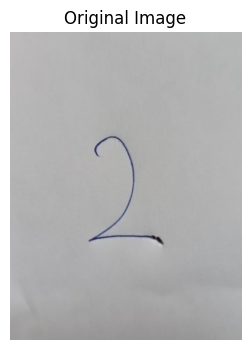

Prediction: 2 (100.0% confidence)


(np.int64(2), np.float32(0.99998987))

In [48]:
image_path = '/content/WhatsApp Image 2026-01-20 at 11.07.10 AM (1).jpeg'
predict_digit(image_path)

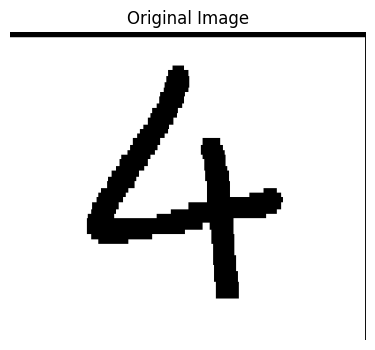

Prediction: 4 (100.0% confidence)


(np.int64(4), np.float32(0.9999989))

In [49]:
image_path = '/content/digit 4.png'
predict_digit(image_path)

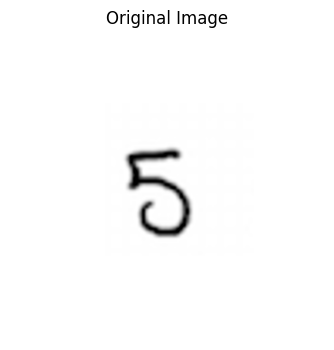

Prediction: 5 (100.0% confidence)


(np.int64(5), np.float32(1.0))

In [52]:
image_path = '/content/digit 5.png'
predict_digit(image_path)